This experiment runs a weak scaling evaluation on a dragonfly network. 

# 0. User Parameters, Imports, Environment

## User Parameters

In [1]:
import os

# Path to the directory containing the merlin benchmark workflow and examples
workflow_dir = '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/'


# Path to the directory where the output of the experiment runs will be stored
experiment_name = 'dragonfly_weak_scaling2'

# Configuration parameters
node_counts = [1,2,4,8,16,32]#,64,128]
total_groups = 128
routers_per_group_per_node = 8
hosts_per_router = 8

# Whether to force re-running experiments even if they have already been completed
# If set to 0, existing results will be used instead of rerunning experiments
FORCED = 1

# Path to the directory containing the apptainer executable
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'

# Path where apptainer should store its cache
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'

# URL of the SST container to be used for the workflow and the destination path where it should be saved.
# If the destination path is already created, the container will not be downloaded and the url will be ignored.
sst_container_url = 'ghcr.io/hpc-ai-adv-dev/sst-perf-track-full:16.0.0'
sst_container_dest_name = 'sst-perf-track-full.sif'


print(f'workflow_dir: {workflow_dir}')

workflow_dir: /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


## Calculated 'Constants'

In [2]:
# Full path to the SST input configuration file
sst_input_config = os.path.join(workflow_dir, 'merlin_benchmark.py')

# Directory containing per-simulation subdirectories
output_dir = os.path.join(workflow_dir, experiment_name + '_out')

# Full path to where the final .sif containerfile will live
sst_container_dest_path = os.path.join(workflow_dir, sst_container_dest_name)

# CSV file containing the consolidated experiment results after all simulations
# have been completed
experiment_result_file = os.path.join(workflow_dir, f'{experiment_name}_results.csv')

sst_input_config
sst_container_dest_path

'/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif'

## Imports

In [3]:
from workflow_utils import *
import os
import sys
sys.path.append(workflow_dir)
import workflow_args
import json
import glob
import humanfriendly
import pandas as pd
from plotnine import *

## Environment + Checks

In [4]:
os.environ["PATH"] += os.pathsep + apptainer_bin_path
#os.environ["PATH"] += os.pathsep + e4s_cl_path
os.environ["LANG"] = "C.UTF-8"
os.environ["LC_ALL"] = "C.UTF-8"
os.environ['APPTAINER_CACHEDIR'] = apptainer_cache_dir

# 1. Download and Prepare Containers

## Download containers, create `.sif`

In [5]:
cd(workflow_dir)

get_convert_to_sif()

# script expects there not to be an extension on the output file name
if os.path.exists(sst_container_dest_path):
    print(f"{sst_container_dest_path} already exists.")
else:
    run_cmd(f"./convert-to-sif.sh {sst_container_url} -o {workflow_dir} -f {sst_container_dest_name.replace('.sif', '')}")



> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif already exists.


## Prepare the e4s-cl profile

In [6]:
run_cmd(f"e4s-cl profile edit --add-files {workflow_dir}")
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.py')
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.so')
run_cmd(f'e4s-cl profile edit --image {sst_container_dest_path}')

> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.py


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.py already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.so


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.so already in profile's files


> e4s-cl profile edit --image /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif


## Check that the profile injects a host MPI

If the selected e4s-cl profile has no MPI library bound, e4s-cl performs no MPI
substitution. The container's own MPI then finds no process manager and falls
back to *singleton init*, so every task silently becomes rank 0 of a 1-rank job
instead of one N-rank simulation.


In [7]:
check_mpi_binding(sst_container_dest_path)

e4s-cl profile : sst-experiments
profile image  : /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif
container SST  : /opt/SST/16.0.0/libexec/sstsim.x
container MPI  : libmpi.so.12
bound host MPI : libmpi_cray.so.12 -> /opt/cray/pe/lib64/libmpi_cray.so.12
bound host PMI : libpals.so.0, libpmi.so.0, libpmi2.so.0
OK: e4s-cl will inject a host MPI into the container.


True

# 2. Build Benchmarks

In [8]:
# Run Make within the container
# We have to create and mount this .conf file for SST to use when running
run_cmd('touch sstsimulator.conf')
run_in_container('make -j10', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')

> touch sstsimulator.conf
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark:/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--pwd', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--bind', 'sstsimulator.conf:/home/users/neth/.sst/sstsimulator.conf', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif', 'bash', '-lc', 'make -j10']
/opt/SST/16.0.0/bin//sst-register merlin_benchmark merlin_benchmark_LIBDIR=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark


# 3. Generate Argument Tuples

In [9]:
run_specs = []
for node_count in node_counts:
        num_groups = total_groups
        routers_per_group = routers_per_group_per_node * node_count
        run_specs += workflow_args.generate_merlin_run_specs(
        node_counts = (node_count,),
        topologies=('dragonfly',),
        global_params={'stop_at': (200),
                       'verbose': 5},
        dragonfly_params={
            'dragonfly_hosts_per_router': (hosts_per_router,),
            'dragonfly_num_groups': (num_groups,),
            'dragonfly_routers_per_group' : (routers_per_group,)
        },
        experiment_name=experiment_name)
print(f"Generated {len(run_specs)} run specifications.")
print(f'Example spec: ', run_specs[0])

Generated 6 run specifications.
Example spec:  MerlinRunSpec(run_id='7995dfd5f1', run_name='dragonfly_weak_scaling2_dragonfly_n1_r1_7995dfd5f1', launcher={'srun': ['--nodes=1', '--ntasks-per-node=1'], 'mpirun': ['-n', '1', '-N', '1']}, sst_args=['--timing-info=3', '--parallel-load=SINGLE'], config_args=['--dragonfly-adaptive-threshold', '2.0', '--dragonfly-algorithm', 'minimal', '--dragonfly-global-routing-mode', 'absolute', '--dragonfly-hosts-per-router', '8', '--dragonfly-intergroup-links', '1', '--dragonfly-num-groups', '128', '--dragonfly-routers-per-group', '8', '--flit-size-bytes', '8', '--link-bw-gbps', '4', '--link-lat-ns', '1', '--stop-at', '200ns', '--tg-input-buf-size', '4kB', '--tg-input-latency', '20ns', '--tg-output-buf-size', '4kB', '--tg-output-latency', '20ns', '--topology', 'dragonfly', '--verbose', '5', '--xbar-bw-gbps', '4'], metadata={'experiment_name': 'dragonfly_weak_scaling2', 'run_name': 'dragonfly_weak_scaling2_dragonfly_n1_r1_7995dfd5f1', 'run_id': '7995dfd5f

# 4. Launch Runs

In [10]:

os.makedirs(output_dir, exist_ok=True)

for run_spec in run_specs:
    run_output_dir = os.path.join(output_dir, run_spec.run_name)
    os.makedirs(run_output_dir, exist_ok=True)
    cd(run_output_dir)

    status_file_path = os.path.join(run_output_dir, 'status.txt')

    if os.path.exists(status_file_path):
        with open(status_file_path, 'r') as f:
            status = f.read().strip()
        if not FORCED and status in ['COMPLETED', 'SUBMITTED']:
            print(f'Skipping {run_spec.run_name} as it is already {status}')
            continue

    log_file = os.path.join(run_output_dir, 'run.log')
    error_file = os.path.join(run_output_dir, 'run.err')
    profiling_output_file = os.path.join(run_output_dir, 'profiling.json')

    param_file = os.path.join(run_output_dir, 'params.json')
    with open(param_file, 'w') as f:
        json.dump(run_spec.to_dict(), f, indent=2)


    srun_part = " ".join(run_spec.launcher["srun"])
    sst_part = " ".join(run_spec.sst_args)
    config_part = " ".join(run_spec.config_args)

    launch_cmd = (
        f"e4s-cl launch srun --output={log_file} --error={error_file} "
        f"{srun_part} \\\n\t -- sst --profiling-output={profiling_output_file} --timing-info=3 {sst_input_config} "
        f"{sst_part} \\\n\t -- {config_part}"
    )

    
    sbatch_script_path = os.path.join(run_output_dir, 'run.sbatch')

    with open(sbatch_script_path, 'w') as f:
        f.write(f"#!/bin/bash\n")
        f.write(f"echo 'LAUNCHED' > {status_file_path}\n")
        f.write(f"{launch_cmd}\n")
        f.write(f"if [ $? -eq 0 ]; then\n")
        f.write(f"    echo 'COMPLETED' > {status_file_path}\n")
        f.write(f"else\n")
        f.write(f"    echo 'FAILED' > {status_file_path}\n")
        f.write(f"fi\n")

    os.chmod(sbatch_script_path, 0o755)

    sbatch_log = os.path.join(run_output_dir, 'sbatch.log')
    sbatch_err = os.path.join(run_output_dir, 'sbatch.err')
    sbatch_cmd = f"sbatch --job-name={experiment_name} --output={sbatch_log} --error={sbatch_err} {srun_part} {sbatch_script_path}"
    sbatch_submit_file = os.path.join(run_output_dir, 'sbatch_submit_cmd.txt')
    with open(sbatch_submit_file, 'w') as f:
        f.write(f"{sbatch_cmd}\n")

    with open(status_file_path, 'w') as f:
        f.write('SUBMITTED\n')
    run_cmd(sbatch_cmd)

    cd(workflow_dir)

> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n1_r1_7995dfd5f1
> sbatch --job-name=dragonfly_weak_scaling2 --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n1_r1_7995dfd5f1/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n1_r1_7995dfd5f1/sbatch.err --nodes=1 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n1_r1_7995dfd5f1/run.sbatch
Submitted batch job 1639239
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n2_r1_8718b876d5
> sbatch --job-name=dragonfly_weak_scaling2 --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragon

Submitted batch job 1639241
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n8_r1_6c4b9bd532
> sbatch --job-name=dragonfly_weak_scaling2 --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n8_r1_6c4b9bd532/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n8_r1_6c4b9bd532/sbatch.err --nodes=8 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n8_r1_6c4b9bd532/run.sbatch
Submitted batch job 1639242
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n16_r1_55bf1cfc07
> sbatch --job-name=dragonfly_weak_scaling2 --output

# 5. Wait for Job Completion

In [11]:
wait_for_jobs(job_name=experiment_name)

Waiting for jobs to complete... Queue length: 6


Waiting for jobs to complete... Queue length: 6
Waiting for jobs to complete... Queue length: 6
Waiting for jobs to complete... Queue length: 5
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 3
Waiting for jobs to complete... Queue length: 3
Waiting for jobs to complete... Queue length: 3
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 1
Waiting for jobs to complete... Queue length: 1


KeyboardInterrupt: 

# 6. Collect Simulation Results

In [12]:
result_files = glob.glob(f'{output_dir}/**/profiling.json', recursive=True)
    
print(result_files)
columns = []
for result_file in result_files:
    column_data = {}
    param_file = result_file.replace('profiling.json', 'params.json')
    if os.path.exists(param_file):
        with open(param_file, 'r') as f:
            params = json.load(f)
            for key, value in params.items():
                column_data[key] = value

    with open(result_file, 'r') as f:
        content = json.load(f)
        regions = content['regions']
        column_data['total_duration_s'] = humanfriendly.parse_timespan(regions['total']['duration'])    
        column_data['build_duration_s'] = humanfriendly.parse_timespan(regions['total']['build']['duration'])
        column_data['execute_duration_s'] = humanfriendly.parse_timespan(regions['total']['execute']['duration'])

        column_data['total_memory_gib'] = humanfriendly.parse_size(regions['total']['total_memory']) / (1024.0 ** 3)
        column_data['build_memory_gib'] = humanfriendly.parse_size(regions['total']['build']['total_memory']) / (1024.0 ** 3)
        column_data['execute_memory_gib'] = humanfriendly.parse_size(regions['total']['execute']['total_memory']) / (1024.0 ** 3)

        column_data['global_max_rss_gib'] = humanfriendly.parse_size(content['resources']['global_max_rss']) / (1024.0 ** 3)
        column_data['local_max_rss_gib'] = humanfriendly.parse_size(content['resources']['local_max_rss']) / (1024.0 ** 3)
        column_data['dragonfly_groups_per_node'] = column_data['dragonfly_num_groups'] / column_data['node_count']
        column_data['dragonfly_num_routers'] = column_data['dragonfly_routers_per_group'] * column_data['dragonfly_num_groups']
    param_file = result_file.replace('profiling.json', 'params.json')
    if os.path.exists(param_file):
        with open(param_file, 'r') as f:
            params = json.load(f)
            for key, value in params.items():
                column_data[key] = value
    #print(column_data)
    columns.append(column_data)


df = pd.DataFrame(columns)

df.to_csv(experiment_result_file, index=False)


['/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n8_r1_6c4b9bd532/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n1_r1_7995dfd5f1/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n4_r1_50f8a52adf/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n2_r1_8718b876d5/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling2_out/dragonfly_weak_scaling2_dragonfly_n16_r1_55bf1cfc07/profiling.json']


# 7. Analyze Results

In [13]:
df = pd.read_csv(experiment_result_file)
df.head()

,run_id,run_name,experiment_name,topology,node_count,rank_count,srun_command,mpirun_command,stop_at,verbose,...,total_duration_s,build_duration_s,execute_duration_s,total_memory_gib,build_memory_gib,execute_memory_gib,global_max_rss_gib,local_max_rss_gib,dragonfly_groups_per_node,dragonfly_num_routers
0,6c4b9bd532,dragonfly_weak_scaling2_dragonfly_n8_r1_6c4b9b...,dragonfly_weak_scaling2,dragonfly,8,1,srun --nodes=8 --ntasks-per-node=1 sst --timin...,mpirun -n 8 -N 1 sst --timing-info=3 --paralle...,200ns,5,...,25.031589,15.331318,9.651603,8.605793,7.618740,8.605793,8.812333,1.103459,16.0,8192
1,7995dfd5f1,dragonfly_weak_scaling2_dragonfly_n1_r1_7995df...,dragonfly_weak_scaling2,dragonfly,1,1,srun --nodes=1 --ntasks-per-node=1 sst --timin...,mpirun -n 1 -N 1 sst --timing-info=3 --paralle...,200ns,5,...,4.068715,3.271991,0.794059,0.517659,0.458531,0.517659,0.530083,0.530083,128.0,1024
2,50f8a52adf,dragonfly_weak_scaling2_dragonfly_n4_r1_50f8a5...,dragonfly_weak_scaling2,dragonfly,4,1,srun --nodes=4 --ntasks-per-node=1 sst --timin...,mpirun -n 4 -N 1 sst --timing-info=3 --paralle...,200ns,5,...,11.536671,7.203371,4.330157,2.841912,2.544364,2.841912,2.910113,0.728859,32.0,4096
3,8718b876d5,dragonfly_weak_scaling2_dragonfly_n2_r1_8718b8...,dragonfly_weak_scaling2,dragonfly,2,1,srun --nodes=2 --ntasks-per-node=1 sst --timin...,mpirun -n 2 -N 1 sst --timing-info=3 --paralle...,200ns,5,...,5.293709,3.990390,1.294482,1.133354,1.012860,1.133354,1.160558,0.581428,64.0,2048
4,55bf1cfc07,dragonfly_weak_scaling2_dragonfly_n16_r1_55bf1...,dragonfly_weak_scaling2,dragonfly,16,1,srun --nodes=16 --ntasks-per-node=1 sst --timi...,mpirun -n 16 -N 1 sst --timing-info=3 --parall...,200ns,5,...,65.792801,38.672461,27.107694,29.412657,25.890861,29.412657,30.118600,1.884932,8.0,16384


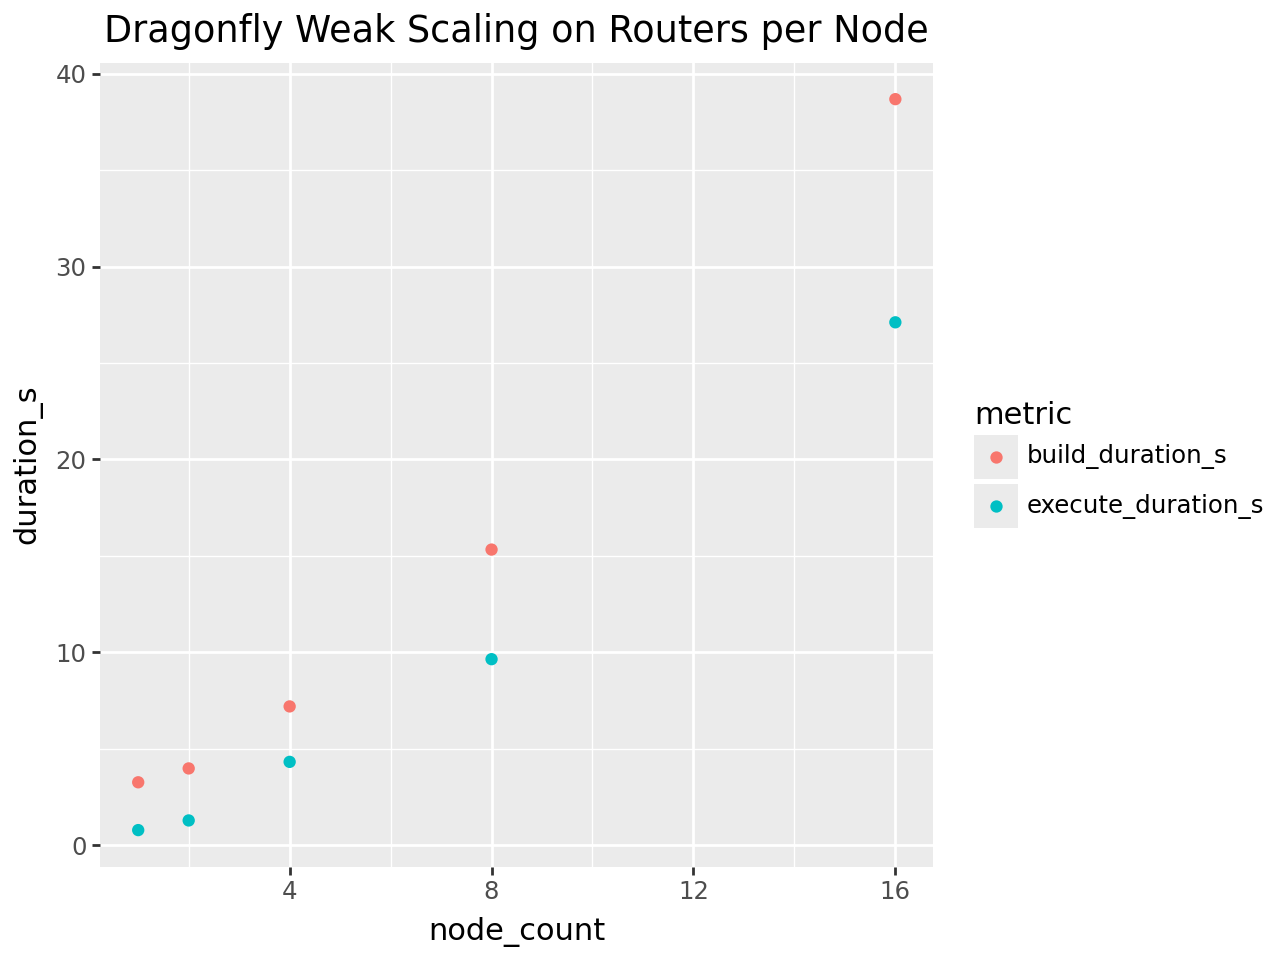

In [14]:
time_df = df.melt(id_vars=['node_count', 'dragonfly_groups_per_node'], value_vars=['build_duration_s', 'execute_duration_s'], var_name='metric', value_name='duration_s')
p = ggplot(time_df, aes(x='node_count', y='duration_s', color='metric'))
p += geom_point()
p += labs(title=f'Dragonfly Weak Scaling on Routers per Node')
p

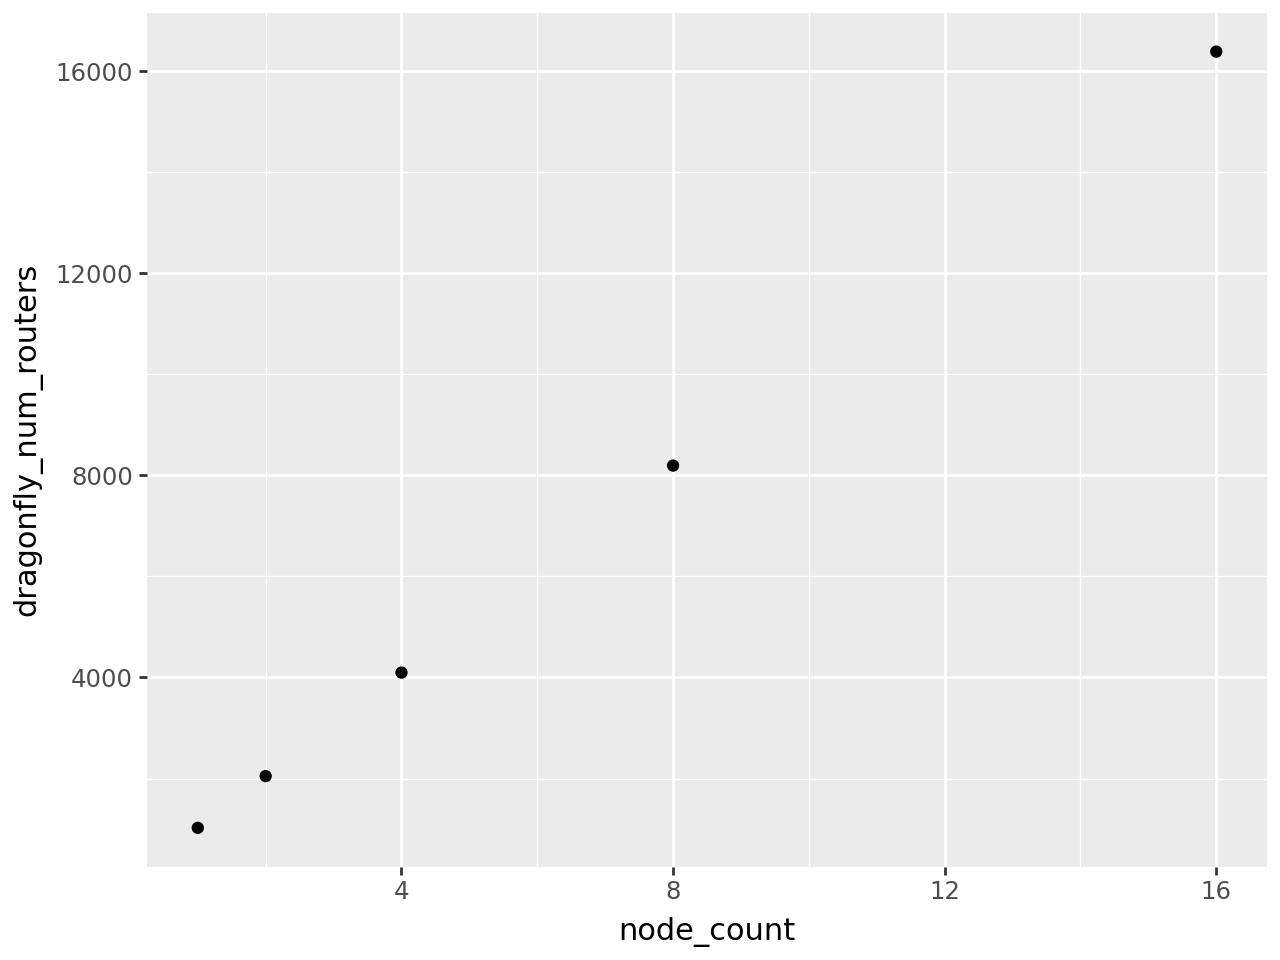

In [15]:
p = ggplot(df, aes(x='node_count', y='dragonfly_num_routers'))
p += geom_point()
p